In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [3]:
def linear_fit_plot(x, y):
    # TO RUN: import numpy as np, matplotlib.pyplot as plt and from scipy.stats import linregress
    result = linregress(x, y)
    m = result.slope
    c = result.intercept
    m_err = result.stderr
    c_err = result.intercept_stderr

    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = m * x_fit + c
    plt.plot(x_fit, y_fit, linestyle='--',label=f'Fitted equation: y = ({m:.3f} ± {m_err:.3f})x + ({c:.3f} ± {c_err:.3f})', color='red', linewidth=2)
    plt.legend()

EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) 
    300 |           17 |               9 |                8 
    330 |         2105 |              29 |             2076 
    360 |         2570 |              39 |             2531 
    390 |         2770 |              37 |             2733 
    420 |         2686 |              39 |             2647 
    450 |         2792 |              32 |             2760 
    480 |         2805 |              38 |             2767 
    510 |         2802 |              29 |             2773 
    540 |         2910 |              38 |             2872 
    570 |         2960 |              35 |             2925 
    600 |         2865 |              37 |             2828 
    630 |         2950 |              52 |             2898 
    660 |         3472 |              50 |             3422 


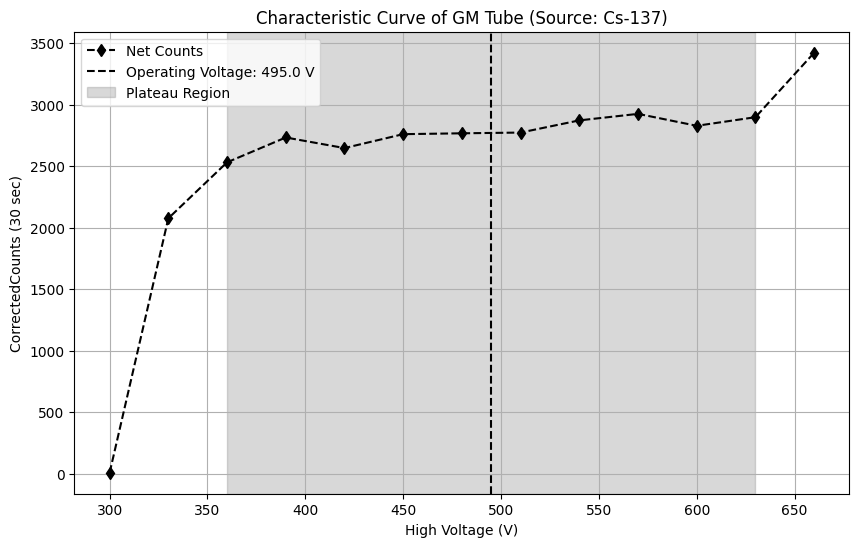

Plateau region: 360 V to 630 V
Operating voltage: 495.0 V
Plateau length: 270 V
Slope of plateau: 5.37%


In [18]:
# Geiger Müller-1 data analysis

# Characteristic curve of GM tube (determine plateau region and operating voltage)
EHT = np.array([300,330,360,390,420,450,480,510,540,570,600,630,660])  # High voltage in volts
Counts = np.array([17,2105,2570,2770,2686,2792,2805,2802,2910,2960,2865,2950,3472])  # in 30 sec
Background = np.array([9,29,39,37,39,32,38,29,38,35,37,52,50])  # Background count in 30 sec
Net_Counts = Counts - Background  # in 30 sec

V1,V2 = 360, 630  # Plateau region voltage range
plateau_length = V2 - V1
V_op = (V1 + V2) / 2  # Operating voltage
Slope_plateau = ((2898 -2531)/2531)*(100/(630-360))*100  # in percentage
# Table of values
print("EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) ")
for i in range(len(EHT)):
    print(f"{EHT[i]:7} | {Counts[i]:12} | {Background[i]:15} | {Net_Counts[i]:16} ")

# Plotting the characteristic curve
plt.figure(figsize=(10, 6))
plt.plot(EHT, Net_Counts, marker='d', linestyle='--', color='black', label='Net Counts')
plt.axvline(V_op, color='black', linestyle='--', label=f'Operating Voltage: {V_op:.1f} V')
plt.title('Characteristic Curve of GM Tube (Source: Cs-137)')
plt.xlabel('High Voltage (V)')
plt.ylabel('CorrectedCounts (30 sec)')
plt.axvspan(V1, V2, alpha=0.3, color='grey', label='Plateau Region')
plt.grid()
plt.legend()
plt.show()

# Summary of results
print(f"Plateau region: {V1} V to {V2} V")
print(f"Operating voltage: {V_op} V")
print(f"Plateau length: {plateau_length} V")
print(f"Slope of plateau: {Slope_plateau:.2f}%")



Distance (cm) | Counts (60s) | Net Counts (60s) | Net Counts/60sec | Product | Transformation (1/cm^2) | Log(Distance) | Log(Net Count Rate)
          2.0 |         4152 |           4082.8 |         68.04667 |  272.19 |                 0.25 |          0.69 |          4.22
          2.5 |         3373 |           3303.8 |         55.06333 |  344.15 |                 0.16 |          0.92 |          4.01
          3.0 |         2736 |           2666.8 |         44.44667 |  400.02 |                 0.11 |          1.10 |          3.79
          3.5 |         2235 |           2165.8 |         36.09667 |  442.18 |                 0.08 |          1.25 |          3.59
          4.0 |         1928 |           1858.8 |         30.98000 |  495.68 |                 0.06 |          1.39 |          3.43
          4.5 |         1504 |           1434.8 |         23.91333 |  484.25 |                 0.05 |          1.50 |          3.17
          5.0 |         1287 |           1217.8 |         20.29667

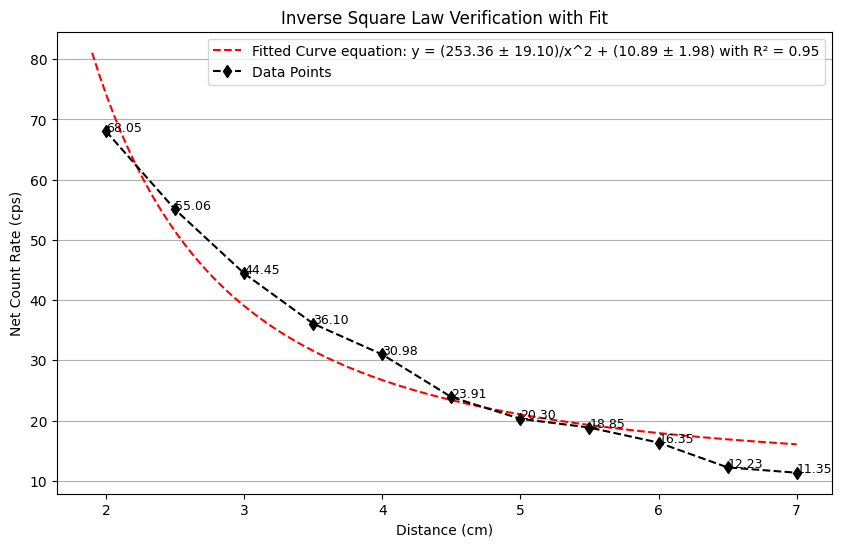

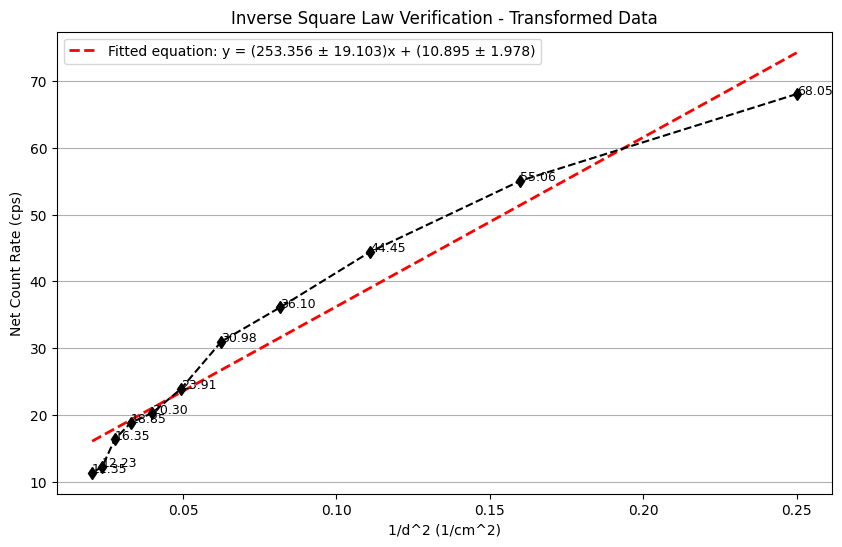

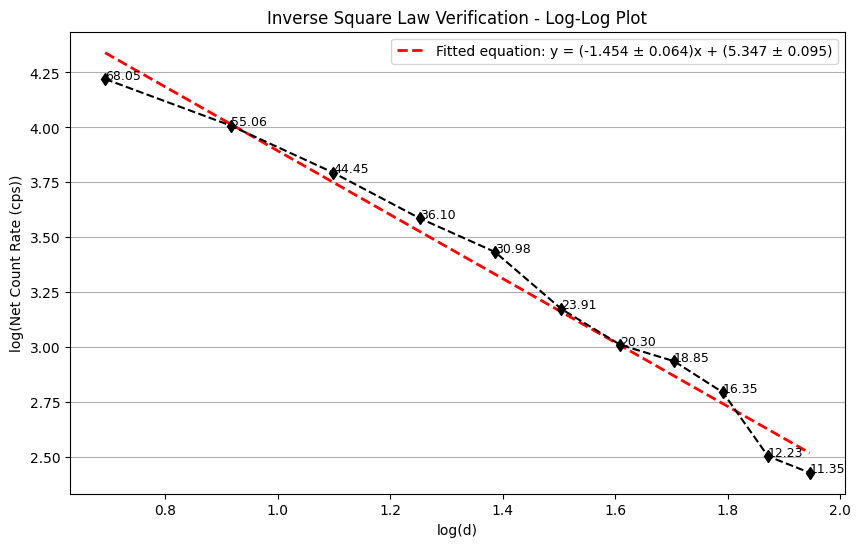

In [19]:
# Inverse square law verification (Cs-137 as a source)
dist = np.array([2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7])  # Distance in cm
Counts = np.array([4152,3373,2736,2235,1928,1504,1287,1200,1050,803,750])  # Counts in 60 sec at operating voltage = 495V
Back_count = np.array([59,76,61,77,73])  # Background count in 60 sec
Net_counts = Counts - Back_count.mean()  # Net counts in 60 sec
Net_count_rate = Net_counts / 60  # Net count rate in cps (R)
Product = Net_count_rate * dist**2  
Transformation = 1 / (dist)**2  # in 1/cm^2
ldis,lrate = np.log(dist), np.log(Net_count_rate)

# Table of values
print("\nDistance (cm) | Counts (60s) | Net Counts (60s) | Net Counts/60sec | Product | Transformation (1/cm^2) | Log(Distance) | Log(Net Count Rate)")
for i in range(len(dist)):
    print(f"{dist[i]:13} | {Counts[i]:12} | {Net_counts[i]:16} | {Net_count_rate[i]:16.5f} | {Product[i]:7.2f} | {Transformation[i]:20.2f} | {ldis[i]:13.2f} | {lrate[i]:13.2f}")
# Plotting the inverse square law verification with fit
def f(x, a, c):
    return a/x**2 + c
popt, pcov = curve_fit(f, dist, Net_count_rate)
coeff_ditermination = 1 - np.sum((Net_count_rate - f(dist, *popt))**2) / np.sum((Net_count_rate - np.mean(Net_count_rate))**2)
a, c = popt
aerr, cerr = np.sqrt(np.diag(pcov))
plt.figure(figsize=(10, 6))
x_fit = np.linspace(1.9, 7, 100)
y_fit = f(x_fit, *popt)
plt.plot(x_fit, y_fit, linestyle = '--',label=f'Fitted Curve equation: y = ({a:.2f} ± {aerr:.2f})/x^2 + ({c:.2f} ± {cerr:.2f}) with R² = {coeff_ditermination:.2f}', color='red')
for i in range(len(dist)):
    plt.text(dist[i], Net_count_rate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')
plt.plot(dist, Net_count_rate, marker='d', linestyle='--', color='black', label='Data Points')
plt.title('Inverse Square Law Verification with Fit')
plt.xlabel('Distance (cm)')
plt.ylabel('Net Count Rate (cps)')
plt.grid(True,axis='y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i in range(len(Transformation)):
    plt.text(Transformation[i], Net_count_rate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')

#fitting R vs 1/d^2 
linear_fit_plot(Transformation, Net_count_rate)
plt.plot(Transformation,Net_count_rate, marker='d', linestyle='--', color='black')
plt.title('Inverse Square Law Verification - Transformed Data')
plt.xlabel('1/d^2 (1/cm^2)')
plt.ylabel('Net Count Rate (cps)')
plt.grid(True,axis='y') 
plt.show()

plt.figure(figsize=(10, 6))
for i in range(len(dist)):
    plt.text(ldis[i], lrate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')
linear_fit_plot(ldis, lrate)
plt.plot(ldis, lrate, marker='d', linestyle='--', color='black')
plt.title('Inverse Square Law Verification - Log-Log Plot')
plt.xlabel('log(d)')
plt.ylabel('log(Net Count Rate (cps))')
plt.grid(True,axis='y')
plt.show()


In [ ]:
# efficiency calculation for gamma source(Cs-137) and beta source(Tl-204)
d = 3 # in cm (aperture diameter)
# For Cs-137 (gamma source)
A_g = 79 # activity in KBq (may 2016)
lambda_g = 0.02297 # decay constant for Cs-137
t = 2025 - 2016 + 11/12  # time in years from may 2016 to april 2026
print('Time =', t, 'years')
A_g = 79*np.exp(-lambda_g * t) # present activity in KBq
print('Present activity for gamma source =', A_g, 'KBq')
# print('time =', t, 'years'+'A_g =', A_g, 'KBq')
Dist_gamma = 10  # Distance in cm 
Nb = [102,100,113] # Background counts in 60 sec 
Ns = [759,683,728] # Source counts in 60 sec 
Net_counts_gamma_rate = (np.array(Ns) - np.array(Nb)) / 60  # Net count rate in cps
# print('Net count rate for gamma source =', Net_counts_gamma_rate, 'cps')
R = A_g*1000*d**2/(16*Dist_gamma**2) # fraction of emitted particles reaching the detector
print('R for gamma source =', R)
Efficiency_gamma = (Net_counts_gamma_rate * 100) / R  # Efficiency % calculation

# For Tl-204 (beta source) 
A_b = 11 # activity in KBq
lambda_b = 0.18337 # decay constant for Tl-204 (assuming same as Cs-137 for this example)
A_b = 11*np.exp(-lambda_b * t) # present activity in KBq
print('Present activity for beta source =', A_b, 'KBq')
Dist_beta = 2  # Distance in cm
Nb_beta = [121,108,107]  # Background counts in 100 sec 
Ns_beta = [1241,1256,1290]  # Source counts in 100 sec
Net_counts_beta_rate = (np.array(Ns_beta) - np.array(Nb_beta)) / 100  # Net count rate in cps
R_beta = A_b*1000*d**2/(16*Dist_beta**2) # fraction of emitted particles reaching the detector
print('R for beta source =', R_beta)
Efficiency_beta = (Net_counts_beta_rate * 100) / R_beta  # Efficiency % calculation
# Table of efficiency results
print("            Gamma Source        |               Beta Source")
print(" Net Counts rate  | Efficiency % | Net Counts rate  | Efficiency %")
for i in range(len(Net_counts_gamma_rate)):
    print(f" {Net_counts_gamma_rate[i]:16.5f} | {Efficiency_gamma[i]:10.5f} || {Net_counts_beta_rate[i]:16.5f} | {Efficiency_beta[i]:10.5f}")

Time = 9.916666666666666 years
Present activity for gamma source = 62.907287728530044 KBq
R for gamma source = 353.8534934729815
1.7851029812271924
R for beta source = 251.03010673507393
            Gamma Source        |               Beta Source
 Net Counts rate  | Efficiency % | Net Counts rate  | Efficiency %
         10.95000 |    3.09450 ||         11.20000 |    4.46162
          9.71667 |    2.74596 ||         11.48000 |    4.57316
         10.25000 |    2.89668 ||         11.83000 |    4.71258


Mean Value | Variance | Standard Deviation
69.00       | 82.88     | 9.10

Mean Value | Ni - mean | (Ni - mean)^2
     69.00 |      2.00 |           4.00
     69.00 |     -9.00 |          81.00
     69.00 |      8.00 |          64.00
     69.00 |    -11.00 |         121.00
     69.00 |      3.00 |           9.00
     69.00 |    -13.00 |         169.00
     69.00 |      0.00 |           0.00
     69.00 |      6.00 |          36.00
     69.00 |      1.00 |           1.00
     69.00 |      1.00 |           1.00
     69.00 |      3.00 |           9.00
     69.00 |     -4.00 |          16.00
     69.00 |    -12.00 |         144.00
     69.00 |     -5.00 |          25.00
     69.00 |     -8.00 |          64.00
     69.00 |     -6.00 |          36.00
     69.00 |      3.00 |           9.00
     69.00 |      9.00 |          81.00
     69.00 |     10.00 |         100.00
     69.00 |     14.00 |         196.00
     69.00 |      4.00 |          16.00
     69.00 |     21.00 |         441.00
     6

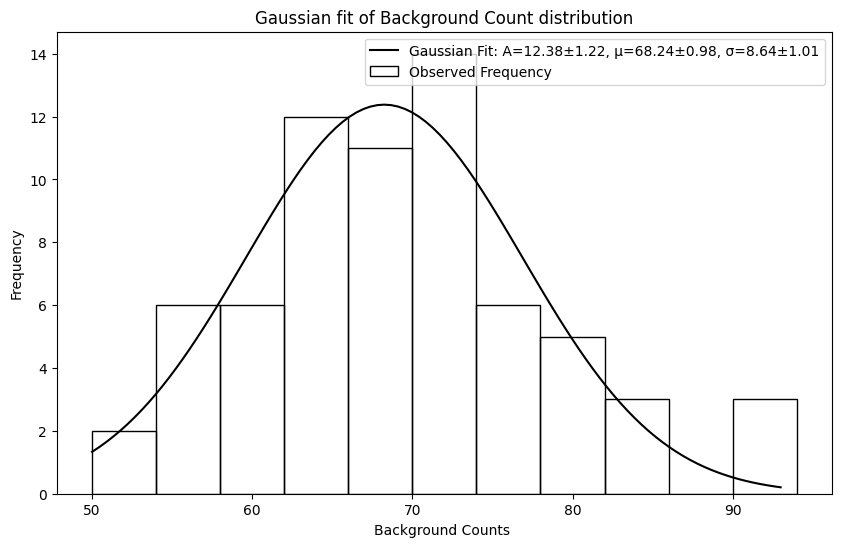


Count | sd_beta | Ni - mean | (Ni - mean)/sd_beta | z-score(rounded) 
  323 |    17.90 |      8.36 |             0.47 |       0.50
  322 |    17.90 |      7.36 |             0.41 |       0.50
  319 |    17.90 |      4.36 |             0.24 |       0.00
  352 |    17.90 |     37.36 |             2.09 |       2.00
  334 |    17.90 |     19.36 |             1.08 |       1.00
  297 |    17.90 |    -17.64 |            -0.99 |      -1.00
  330 |    17.90 |     15.36 |             0.86 |       1.00
  319 |    17.90 |      4.36 |             0.24 |       0.00
  327 |    17.90 |     12.36 |             0.69 |       0.50
  287 |    17.90 |    -27.64 |            -1.54 |      -1.50
  287 |    17.90 |    -27.64 |            -1.54 |      -1.50
  310 |    17.90 |     -4.64 |            -0.26 |      -0.50
  327 |    17.90 |     12.36 |             0.69 |       0.50
  348 |    17.90 |     33.36 |             1.86 |       2.00
  311 |    17.90 |     -3.64 |            -0.20 |      -0.00
  299 |    17.

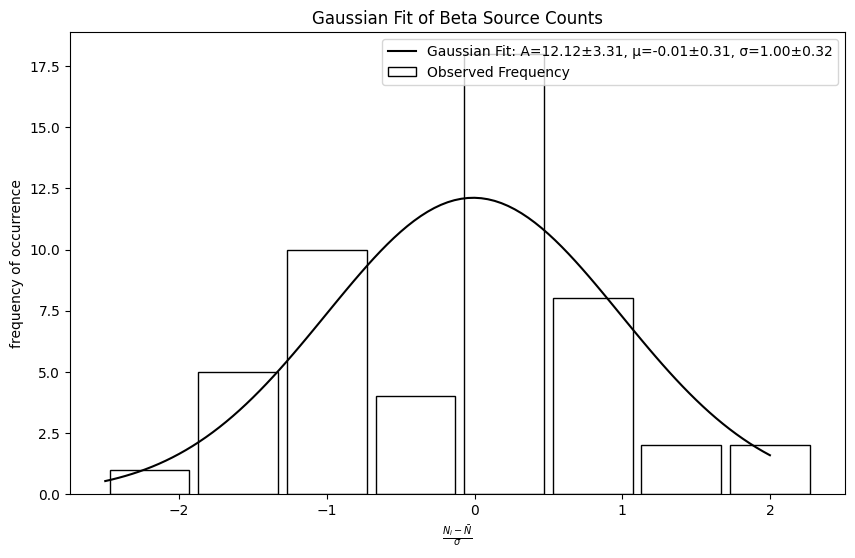

Direct data results 
Mean Value | Variance | Standard Deviation
314.64       | 320.31     | 17.90


In [97]:
# Statistical error analysis for gamma source
bg_counts = [
    71, 60, 77, 58, 72, 56, 69, 75, 70, 70, 72, 65, 57, 64, 61, 63, 72, 78,
    79, 83, 73, 90, 62, 82, 67, 68, 82, 93, 74, 75, 80, 57, 69, 93, 77, 69, 62,
    65, 65, 72, 66, 56, 70, 80, 62, 59, 62, 63, 58, 77, 71, 71, 69, 68, 62, 67,
    64, 52, 60, 81, 50, 70, 57, 72, 72, 69, 57, 68 ]  # Background counts in 60 sec

# statistical results
Mean_value = round(np.mean(bg_counts),0)  # Mean background count rate in cps
dev = np.array(bg_counts) - Mean_value # Deviation from average
Variance = np.sum(dev**2) / len(bg_counts) # Sample variance
sd_ = np.sqrt(Variance)  # Standard deviation

print("Mean Value | Variance | Standard Deviation")
print(f"{Mean_value:.2f}       | {Variance:.2f}     | {sd_:.2f}") 

# Table of statistical analysis results
print("\nMean Value | Ni - mean | (Ni - mean)^2")
for i in range(len(bg_counts)):
    print(f"{Mean_value:10.2f} | {dev[i]:9.2f} | {(dev[i])**2:14.2f}")

# plot for background count rate hist and fit with gaussian using curve fit
plt.figure(figsize=(10, 6))
def gaussian(x, A, mu, sigma):
    return (A * np.exp(-0.5 * ((x - mu) / sigma)**2))
bb = np.arange(min(bg_counts), max(bg_counts) + 4, 4)  # bin edges with width of 4
freq, bin_edges = np.histogram(bg_counts, bins=bb)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
popt, pcov = curve_fit(gaussian, bin_centers, freq, p0=[max(freq), np.mean(bg_counts), np.std(bg_counts )])
A_fit, mu_fit, sigma_fit = popt
A_err, mu_err, sigma_err = np.sqrt(np.diag(pcov))
x = np.linspace(min(bg_counts), max(bg_counts), 100)
y = gaussian(x, *popt)
plt.plot(x, y, color='black', label=f'Gaussian Fit: A={A_fit:.2f}±{A_err:.2f}, μ={mu_fit:.2f}±{mu_err:.2f}, σ={sigma_fit:.2f}±{sigma_err:.2f}')
plt.bar(bin_centers, freq, width=4,edgecolor='black', fill=False, label='Observed Frequency')
plt.title('Gaussian fit of Background Count distribution')
plt.xlabel('Background Counts ')
plt.ylabel('Frequency')
plt.legend()
plt.grid(False)
plt.show()

# with beta source 
counts_beta = [
    323, 322, 319, 352, 334, 297, 330, 319, 327, 287,
    287, 310, 327, 348, 311, 299, 292, 329, 269, 332,
    337, 323, 300, 305, 344, 292, 334, 299, 322, 316,
    315, 294, 339, 317, 318,
    308, 314, 319, 330, 322, 296, 301, 300, 295, 328,
    301, 332, 284, 325, 308 ] # in 25 sec
mean = np.mean(counts_beta)  # Mean count rate
dev_beta = np.array(counts_beta) - mean  # Deviation from mean
sd_beta = np.sqrt(np.sum(dev_beta**2) / len(counts_beta))  # Standard deviation (Poisson distribution)
z_scores = dev_beta / sd_beta  # Standard score (z-score) for each count
def rd(x): #Round of the nearest 0.5 
    return np.round(x * 2) / 2
Zr = rd(z_scores)  # Rounded z-scores to the nearest 0.5 
print("\nCount | sd_beta | Ni - mean | (Ni - mean)/sd_beta | z-score(rounded) ")
for i in range(len(counts_beta)):
    print(f"{counts_beta[i]:5} | {sd_beta:8.2f} | {dev_beta[i]:9.2f} | {z_scores[i]:16.2f} | {Zr[i]:10.2f}")

plt.figure(figsize=(10, 6))
# fitting gaussian to beta source counts
def gaussian_beta(x, A, mu, sigma):
    return (A * np.exp(-0.5 * ((x - mu) / sigma)**2))
bb1 = np.arange(min(Zr), max(Zr) + 0.6, 0.6)  # bin edges with width of 4
freq_beta, bin_edges_beta = np.histogram(Zr, bins=bb1)
bin_centers_beta = (bin_edges_beta[:-1] + bin_edges_beta[1:]) / 2
popt_beta, pcov_beta = curve_fit(gaussian_beta, bin_centers_beta, freq_beta, p0=[max(freq_beta),0,1])
A_fit_beta, mu_fit_beta, sigma_fit_beta = popt_beta
A_err_beta, mu_err_beta, sigma_err_beta = np.sqrt(np.diag(pcov_beta))
x_beta = np.linspace(min(Zr), max(Zr), 100)
y_beta = gaussian_beta(x_beta, *popt_beta)
plt.plot(x_beta, y_beta, color='black', label=f'Gaussian Fit: A={A_fit_beta:.2f}±{A_err_beta:.2f}, μ={mu_fit_beta:.2f}±{mu_err_beta:.2f}, σ={sigma_fit_beta:.2f}±{sigma_err_beta:.2f}')
plt.bar(bin_centers_beta, freq_beta, width=0.6*0.9,edgecolor='black', fill=False,label='Observed Frequency')
plt.title('Gaussian Fit of Beta Source Counts')
plt.xlabel(r"$\frac{N_i - \bar{N}}{\sigma}$")
plt.ylabel('frequency of occurrence')
plt.legend()
plt.grid(False)
plt.show()

print("Direct data results ")
print("Mean Value | Variance | Standard Deviation")
print(f"{mean:.2f}       | {sd_beta**2:.2f}     | {sd_beta:.2f}") 


EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s)
    330 |            0 |               0 |                0 
    360 |         1579 |              29 |             1550 
    390 |         1688 |              37 |             1651 
    420 |         1733 |              37 |             1696 
    450 |         1636 |              39 |             1597 
    480 |         1646 |              38 |             1608 
    510 |         1653 |              26 |             1627 
    540 |         1819 |              35 |             1784 
    571 |         1763 |              31 |             1732 
    600 |         1726 |              36 |             1690 
    630 |         3417 |              76 |             3341 


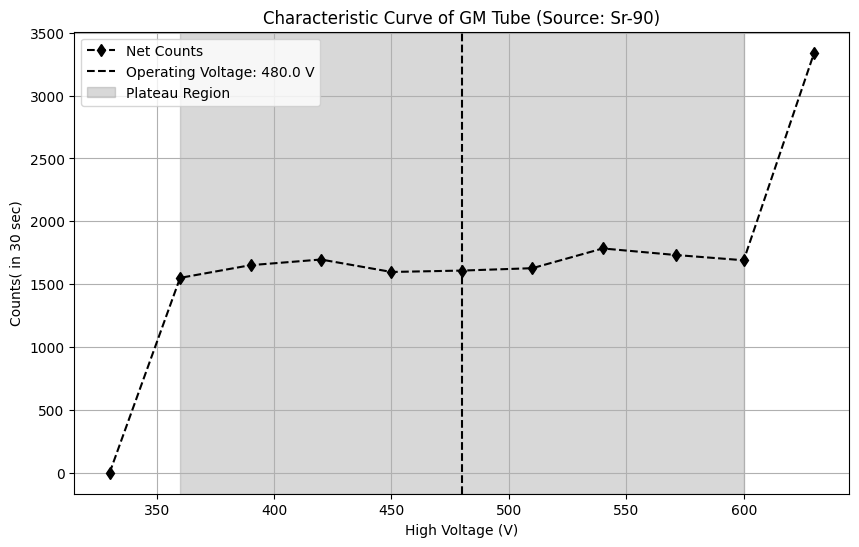

Plateau region: 360 V to 600 V
Operating voltage: 480.0 V
Plateau length: 240 V
Slope of plateau: 3.76%


In [69]:
# GM-2 Analysis
#  Characteristic curve of GM tube (determine plateau region and operating voltage)
EHT = np.array([330,360,390,420,450,480,510,540,571,600,630])  # High voltage in volts
Counts = np.array([0,1579,1688,1733,1636,1646,1653,1819,1763,1726,3417])  # in 30 sec
Background = np.array([0,29,37,37,39,38,26,35,31,36,76])  # Background count in 30 sec
Net_Counts = Counts - Background  # in 30 sec

V1,V2 = 360, 600  # Plateau region voltage range
plateau_length = V2 - V1
V_op = (V1 + V2) / 2  # Operating voltage
Slope_plateau = ((1690 -1550)/1550)*(100/(600-360))*100  # in percentage
# Table of values
print("EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s)")
for i in range(len(EHT)):
    print(f"{EHT[i]:7} | {Counts[i]:12} | {Background[i]:15} | {Net_Counts[i]:16} ")

# Plotting the characteristic curve
plt.figure(figsize=(10, 6))
plt.plot(EHT, Net_Counts, marker='d', linestyle='--', color='black', label='Net Counts')
plt.axvline(V_op, color='black', linestyle='--', label=f'Operating Voltage: {V_op:.1f} V')
plt.title('Characteristic Curve of GM Tube (Source: Sr-90)')
plt.xlabel('High Voltage (V)')
plt.ylabel('Counts( in 30 sec)')
plt.axvspan(V1, V2, alpha=0.3, color='grey', label='Plateau Region')
plt.grid()
plt.legend()
plt.show()

# Summary of results
print(f"Plateau region: {V1} V to {V2} V")
print(f"Operating voltage: {V_op} V")
print(f"Plateau length: {plateau_length} V")
print(f"Slope of plateau: {Slope_plateau:.2f}%")

Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)
          0.00 |                0.00 |         6713 |          6523.00 |             36.24
          0.05 |               13.55 |         4782 |          4592.00 |             25.51
          0.10 |               27.10 |         3959 |          3769.00 |             20.94
          0.15 |               40.65 |         3475 |          3285.00 |             18.25
          0.20 |               54.20 |         2930 |          2740.00 |             15.22
          0.25 |               67.75 |         2649 |          2459.00 |             13.66
          0.30 |               81.30 |         2401 |          2211.00 |             12.28
          0.35 |               94.85 |         2153 |          1963.00 |             10.91


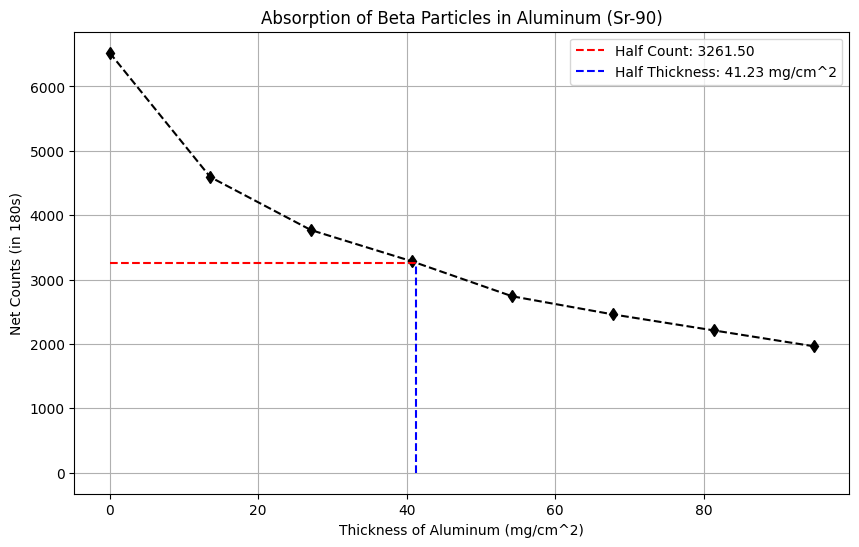


Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)
          0.00 |                0.00 |         1097 |           900.00 |              5.00
          0.05 |               13.55 |          703 |           506.00 |              2.81
          0.10 |               27.10 |          543 |           346.00 |              1.92
          0.15 |               40.65 |          440 |           243.00 |              1.35
          0.20 |               54.20 |          335 |           138.00 |              0.77
          0.25 |               67.75 |          294 |            97.00 |              0.54
          0.30 |               81.30 |          298 |           101.00 |              0.56


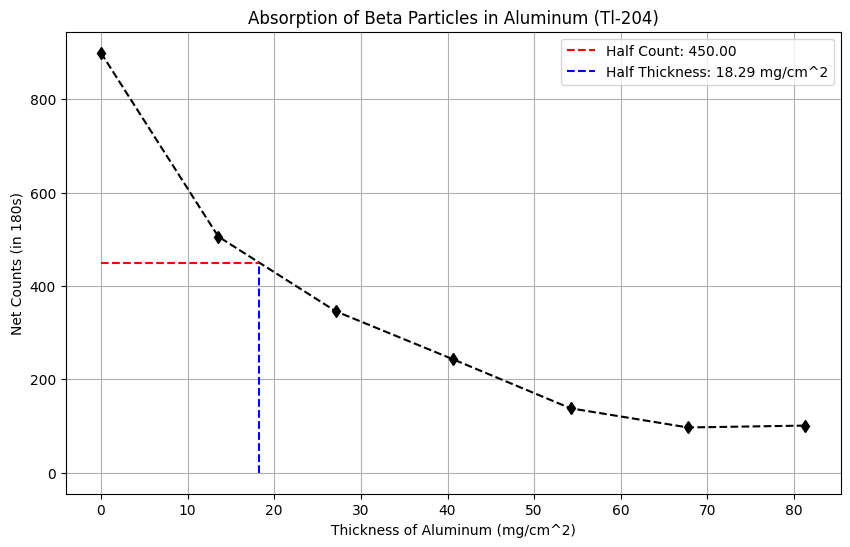

Range of beta particles in aluminum: 0.69203 g/cm^2
End point energy of beta particles: 1.50 MeV


In [71]:
# absorption of beta particles in aluminum (half thickness method) Sr-90
thickness = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3,0.35])  # Thickness in mm
thick2 = thickness* 2.71*100  # in mg/cm^2 (density of aluminum = 2.71 g/cm^3)
counts_beta = np.array([6713,4782,3959,3475,2930,2649,2401,2153])  # Counts in 180 sec for each thickness
back = np.array([51,77,63,57,68])  # Background counts in 60 sec
back_rate = np.mean(back) / 60  # Background count rate in cps
Net_counts_beta = counts_beta - round(back_rate * 180, 0)  # Net counts in 180 sec
Net_count_rate_beta = Net_counts_beta / 180  # Net count rate in cps

# Table of beta absorption analysis
print("Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)")
for i in range(len(thickness)):
    print(f"{thickness[i]:14.2f} | {thick2[i]:19.2f} | {counts_beta[i]:12} | {Net_counts_beta[i]:16.2f} | {Net_count_rate_beta[i]:17.2f}")

half_count = Net_counts_beta[0] / 2  # Half of the initial count for Sr-90
t_half_ = ((54.2-40.65)/(2740 - 3285))*(half_count-3285) + 40.65
# Plotting the absorption curve
plt.figure(figsize=(10, 6))
plt.plot(thick2, Net_counts_beta, marker='d', linestyle='--', color='black')
plt.hlines(half_count, xmin=0, xmax=t_half_, color='r', linestyle='--', label=f'Half Count: {half_count:.2f}')
plt.vlines(t_half_, ymin=0, ymax=half_count, color='b', linestyle='--', label=f'Half Thickness: {t_half_:.2f} mg/cm^2')
plt.title('Absorption of Beta Particles in Aluminum (Sr-90)')
plt.xlabel('Thickness of Aluminum (mg/cm^2)')
plt.ylabel('Net Counts (in 180s)')
plt.legend()
plt.grid()
plt.show()

# absorption of beta particles in aluminum (half thickness method) Tl-204
thickness_tl = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3])  # Thickness in mm
thick2_tl = thickness_tl * 2.71*100  # in mg/cm^2 (density of aluminum = 2.71 g/cm^3)
counts_tl = np.array([1097,703,543,440,335,294,298])  # Counts in 180 sec for each thickness
back_tl = np.array([73,67,51,71,67])  # Background counts in 60 sec
back_rate_tl = np.mean(back_tl) / 60 # Background count rate in cps
Net_counts_tl = counts_tl - round(back_rate_tl * 180, 0)  # Net counts in 180 sec

Net_count_rate_tl = Net_counts_tl / 180  # Net count rate in cps
 
# Table of beta absorption analysis for Tl-204
print("\nThickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)")
for i in range(len(thickness_tl)):
    print(f"{thickness_tl[i]:14.2f} | {thick2_tl[i]:19.2f} | {counts_tl[i]:12} | {Net_counts_tl[i]:16.2f} | {Net_count_rate_tl[i]:17.2f}")
half_count_tl = Net_counts_tl[0] / 2  # Half of the initial count for Tl-204
t_half = ((27.1-13.55)/(346-506))*(half_count_tl-506) + 13.55
# Plotting the absorption curve for Tl-204
plt.figure(figsize=(10, 6))
plt.plot(thick2_tl, Net_counts_tl, marker='d', linestyle='--', color='black')
plt.hlines(half_count_tl, xmin=0, xmax=t_half, color='r', linestyle='--', label=f'Half Count: {half_count_tl:.2f}')
plt.vlines(t_half, ymin=0, ymax=half_count_tl, color='b', linestyle='--', label=f'Half Thickness: {t_half:.2f} mg/cm^2')
plt.title('Absorption of Beta Particles in Aluminum (Tl-204)')
plt.xlabel('Thickness of Aluminum (mg/cm^2)')
plt.ylabel('Net Counts (in 180s)')
plt.grid()
plt.legend()
plt.show()

# Claculation of range of beta particles
R_tl = 0.307 # in g/cm^2 
R_beta = R_tl * (t_half_ / t_half)  # Range of beta particles in g/cm^2
print(f"Range of beta particles in aluminum: {R_beta:.5f} g/cm^2")
End_point_energy = (R_beta +0.09)/0.52 # in MeV (using empirical relation for beta particles)
print(f"End point energy of beta particles: {End_point_energy:.2f} MeV")


Thickness (mm) | Counts (200s) | Net Counts (200s)
          0.00 |        209.0 |             0.00
          0.05 |        231.0 |            22.00
          0.10 |        228.0 |            19.00
          0.20 |        267.0 |            58.00
          0.25 |        249.0 |            40.00
          0.30 |        260.0 |            51.00
          0.35 |        266.0 |            57.00
          0.40 |        258.0 |            49.00
          0.45 |        275.0 |            66.00
          0.50 |        274.0 |            65.00
          0.55 |        249.0 |            40.00
          0.60 |        291.0 |            82.00
          0.65 |        285.5 |            76.50


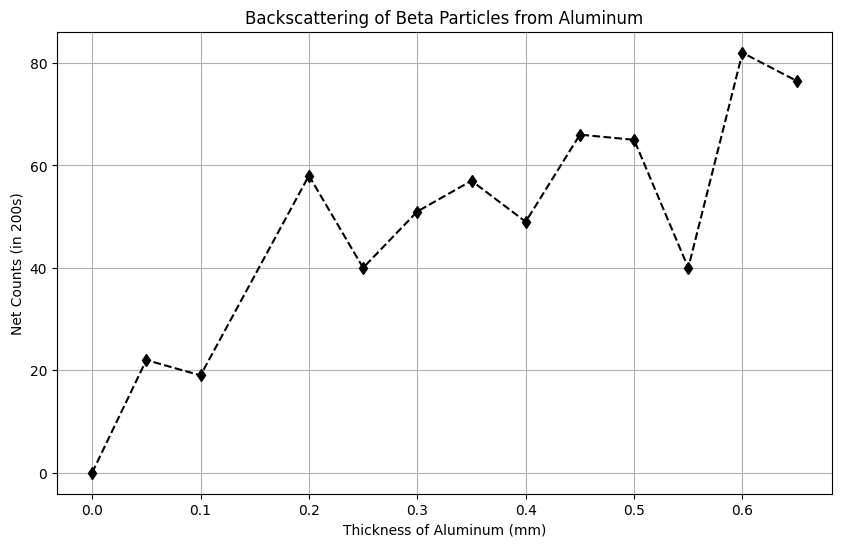

In [17]:
# Backscattering of beta particles from aluminum
thickness_back = np.array([0, 0.05, 0.1, 0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65])  # Thickness in mm (removed  4ht data)
counts_back = np.array([209,np.mean([226,236]),np.mean([223,233]),267,249,260,266,258,275,274,249,291,np.mean([266,305])])  # Counts in 200 sec for each thickness
net_counts_back = counts_back - counts_back[0]  # Net counts in 200 sec

# Table of backscattering analysis
print("\nThickness (mm) | Counts (200s) | Net Counts (200s)")
for i in range(len(thickness_back)):
    print(f"{thickness_back[i]:14.2f} | {counts_back[i]:12} | {net_counts_back[i]:16.2f}")

# Plotting the backscattering curve
plt.figure(figsize=(10, 6))
plt.plot(thickness_back, net_counts_back, marker='d', linestyle='--', color='black')
plt.title('Backscattering of Beta Particles from Aluminum')
plt.xlabel('Thickness of Aluminum (mm)')
plt.ylabel('Net Counts (in 200s)')
plt.grid()
plt.show()